In [2]:
import cga_utils
import prompt_versions
%load_ext autoreload
%autoreload 2

In [3]:
from langchain.globals import set_llm_cache
from langchain_community.cache import SQLiteCache

set_llm_cache(SQLiteCache(database_path=".langchain.ollama24_3_2.db"))

In [4]:
from langchain_community.chat_models import ChatOllama
llm = ChatOllama(model="qwen3:4b", temperature = 0.0, top_p = 1, repeat_penalty=1, presence_penalty=0, frequency_penalty=0)  # vagy bármely más elérhető Ollama modell

# Calc global Performance

In [5]:
%%time
import pandas as pd
messages = prompt_versions.prompt_versions['V18']
messages = [(a, t.replace('/no_think','')) for (a,t)  in messages]
messages[-1] = ( messages[-1][0],  messages[-1][1] + "/no_think" ) 



#problematic_qids = list(pd.read_csv('res/e37.csv').query('error_code == "selection_error" and calc_pattern == "(#+#)/#"')['qid'])

#res = cga_utils.execute_datset_predictions(llm, messages, problematic_qids)
res = cga_utils.execute_dataset_predictions(llm, messages)

1756393764.2930107


0it [00:00, ?it/s]

b2786c1a-37de-4120-b03c-32bf5c81f157
What was the change in the amount for Appliances in 2019 from 2018? Success: -94.0
<< 680-774 || [680.0, 774.0] || [680.0, 774.0] || True >>
fe11f001-3bfe-4089-8108-412676f0a780
What was the percentage change in the amount for Appliances in 2019 from 2018? Success: -12.14
<< (680-774)/774 || [680.0, 774.0, -12.144702842377262] || [680.0, 774.0, 774.0] || True >>
5103aed0-b4e8-4fae-bf78-e2c9f4ba84cf
What is the difference between the domestic and international discount rates as at September 30, 2019? Success: 2.1
<< 4.00 - 1.90  || [4.0, 1.9] || [4.0, 1.9] || True >>
4dc8be43-d8d9-4b08-9ffd-9c19012361ce
What is the year on year percentage change in domestic discount rate between 2018 and 2019? Success: 6.67
<< (4.00 - 3.75)/3.75  || [3.75, 4.0, 6.666666666666667] || [4.0, 3.75, 3.75] || True >>
6c44a1a8-0785-43a0-90ab-7e21df2c57d9
What is the year on year percentage change in international expected return on plan assets between 2018 and 2019? Success

In [6]:
annotated_results = cga_utils.annotate_results(res)
#annotated_results.to_csv('res/Ollama_2_gemma3n_e4b_code_values_v11_m1.csv')
cga_utils.calc_overall_value_match(annotated_results)

Annotaion warning:  EOL while scanning string literal (<unknown>, line 1295)


0.7565392354124748

In [7]:

cga_utils.calc_overall_em(annotated_results)

0.5995975855130785

In [8]:
annotated_results.to_csv('res/e38_18.csv')

In [9]:
len(res)

497

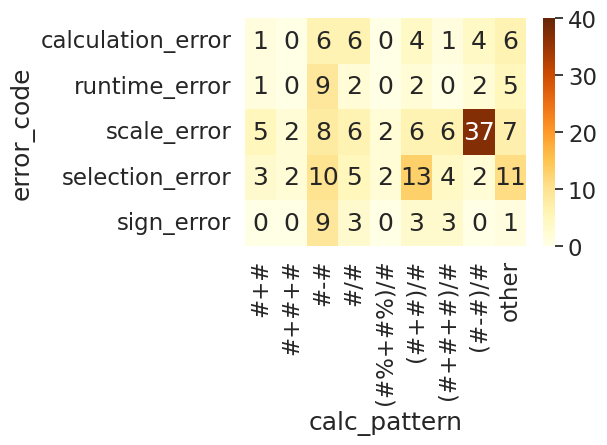

199

In [14]:
df = annotated_results.query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', 40, 0,3, "imgs/heatmap_v18.png")
len(df)

# Other versions

In [13]:
%%time
import pandas as pd
messages = prompt_versions.prompt_versions['V18r']
messages = [(a, t.replace('/no_think','')) for (a,t)  in messages]
messages[-1] = ( messages[-1][0],  messages[-1][1] + "/no_think" ) 



#problematic_qids = list(pd.read_csv('res/e37.csv').query('error_code == "selection_error" and calc_pattern == "(#+#)/#"')['qid'])

#res = cga_utils.execute_datset_predictions(llm, messages, problematic_qids)
res = cga_utils.execute_dataset_predictions(llm, messages)

1755868071.1872754


0it [00:00, ?it/s]

b2786c1a-37de-4120-b03c-32bf5c81f157
What was the change in the amount for Appliances in 2019 from 2018? Success: -94.0
<< 680-774 || [680.0, 774.0, -94.0] || [680.0, 774.0] || True >>
fe11f001-3bfe-4089-8108-412676f0a780
What was the percentage change in the amount for Appliances in 2019 from 2018? Success: -12.14
<< (680-774)/774 || [680.0, 774.0, -12.144702842377262] || [680.0, 774.0, 774.0] || True >>
5103aed0-b4e8-4fae-bf78-e2c9f4ba84cf
What is the difference between the domestic and international discount rates as at September 30, 2019? Success: 2.1
<< 4.00 - 1.90  || [4.0, 1.9] || [4.0, 1.9] || True >>
4dc8be43-d8d9-4b08-9ffd-9c19012361ce
What is the year on year percentage change in domestic discount rate between 2018 and 2019? Success: 6.67
<< (4.00 - 3.75)/3.75  || [3.75, 4.0, 6.666666666666667] || [4.0, 3.75, 3.75] || True >>
6c44a1a8-0785-43a0-90ab-7e21df2c57d9
What is the year on year percentage change in international expected return on plan assets between 2018 and 2019? 

In [34]:
annotated_results = cga_utils.annotate_results(res)
#annotated_results.to_csv('res/Ollama_2_gemma3n_e4b_code_values_v11_m1.csv')
cga_utils.calc_overall_value_match(annotated_results)

0.772635814889336

In [33]:
cga_utils.calc_overall_em(annotated_results)

0.6237424547283702

In [32]:
annotated_results.to_csv('res/e38_18r.csv')

In [31]:
annotated_results["code_calc_pattern"].isna().sum()

0

In [75]:
annotated_results[annotated_results['error_code'] == 'sign_error']

,qid,question,derivation,calc_pattern,pred,pred_scale,answer,scale,value_match,selection_success,...,is_parenth_in_table,has_code_abs,error_text,value_list,code,selected_values,needed_values,exact_match,error_code,aggr_calc_pattern
30,010df393-a62e-408d-888a-045a4e435e6a,What is the difference in amount between Defer...,"(38,476-24,264)",#-#,-14212.0,,14212.00,thousand,False,True,...,True,False,,"[{'number_value': 19373.0, 'scale': '', 'categ...",def run(value_list):\n deferred_revenue_as_...,"[24264.0, 38476.0]","[38476.0, 24264.0]",False,sign_error,#-#
69,f1034ee7-b182-48d5-bad8-1d9902500f57,What is the difference in the number of rights...,"5,691,731 - 4,465,617",#-#,-1226114.0,,1226114.00,,False,True,...,True,False,,"[{'number_value': 10692594.0, 'scale': '', 'ca...",def run(value_list):\n granted_2019 = next(...,"[4465617.0, 5691731.0, -1226114.0]","[5691731.0, 4465617.0]",False,sign_error,#-#
103,9750180c-588d-4ba3-bc94-297d64b50e44,What is the percentage constitution of Depreci...,111 / 372,#/#,-29.84,percent,29.84,percent,False,True,...,True,False,,"[{'number_value': 1671.0, 'scale': 'million', ...",def run(value_list):\n for item in value_li...,"[-111.0, 372.0]",[372.0],False,sign_error,#/#
125,163f08ab-cfae-426a-9c03-4f84feba3bb6,What was the average Net cash used in financin...,(709 + 707 + 429) / 3,(#+#+#)/#,-615.0,million,615.00,million,False,True,...,True,False,,"[{'number_value': 992.0, 'scale': 'million', '...",def run(value_list):\n # Filter for Net cas...,[-615.0],[],False,sign_error,(#+#+#)/#
147,0b7463b3-ed9e-47a0-b838-b26e0ab886eb,What is the change in Allowance for expected c...,135-23,#-#,-112.0,thousand,112.00,thousand,False,True,...,True,False,,"[{'number_value': 3770.0, 'scale': 'thousand',...",def run(value_list):\n for item in value_li...,"[-135.0, -23.0]",[],False,sign_error,#-#
159,fd59c14d-0312-4725-92d8-5c30cd5c5c7a,What is the increase/ (decrease) in Voyage exp...,"21,387-28,237",#-#,6850.0,thousand,-6850.00,thousand,False,True,...,True,False,,"[{'number_value': 601256.0, 'scale': 'thousand...",def run(value_list):\n voyage_2019 = next(i...,"[-21387.0, -28237.0, 6850.0]",[],False,sign_error,#-#
195,3502f875-f816-4a00-986c-fef9b08c0f96,What is the COGS for 2019?,"54,229 - 222,859",#-#,168630.0,,-168630.00,thousand,False,True,...,True,False,,"[{'number_value': 54229.0, 'scale': '', 'categ...",def run(value_list):\n for item in value_li...,"[222859.0, 54229.0, 168630.0]","[54229.0, 222859.0]",False,sign_error,#-#
208,c91ad938-6ad1-4481-8f6b-43ccd2f69926,What is the nominal difference for ROFE betwee...,17.1 - 15.2,#-#,-1.9,percent,1.90,percent,False,True,...,True,False,,"[{'number_value': 8657.0, 'scale': 'million', ...",def run(value_list):\n for item in value_li...,"[15.2, 17.1]","[17.1, 15.2]",False,sign_error,#-#
212,bdcabe8e-6738-47d3-8412-40e5e9a359d0,What is the average voyage expenses in 2018 an...,"(165,012 + 141,770)/2",(#+#)/#,-153391.0,,153391.00,thousand,False,True,...,True,False,,"[{'number_value': 317220.0, 'scale': '', 'cate...",def run(value_list):\n voyage_expenses_2018...,"[-165012.0, -141770.0, -153391.0]",[],False,sign_error,(#+#)/#
237,524463b6-b8d7-410d-926a-699f7b7cdd99,What is the difference between the net cash us...,"(-42,056)-(-9,982)",(-#)-(-#),32074.0,million,-32074.00,million,False,True,...,True,False,,"[{'number_value': 14551.0, 'scale': 'million',...",def run(value_list):\n for item in value_li...,"[-9982.0, -42056.0]",[],False,sign_error,other


#### snipets

In [24]:
import pandas as pd
messages = prompt_versions.prompt_versions['V18']
messages = [(a, t.replace('/no_think','')) for (a,t)  in messages]
messages[-1] = ( messages[-1][0],  messages[-1][1] + "/no_think" ) 


import pandas as pd
import cga_utils
from tatqa_metric import TaTQAEmAndF1

dataset = pd.read_json('dataset_raw/tatqa_dataset_dev.json')    

_table, _q =  cga_utils.get_question(dataset, "79f06004-f4fc-4e82-a9fe-3c389a2f81b6")
                    
table = _table['table']

q = _q['question']
print(q, end='')

r = []

(pred, pred_scale, trace) = cga_utils.get_answer_with_trace(llm, messages, table,_q)
(pred, pred_scale, trace)
metrics23 = TaTQAEmAndF1()

ans = {"answer_type":_q["answer_type"], "answer": _q["answer"], 'scale': _q["scale"]}

metrics23(ans, pred, pred_scale)
pred_em, pred_f1, scale_score, op_score = metrics23.get_overall_metric(reset=True)
pred_em


What was the change in the statutory federal income tax rate from 2018 to 2019?

1.0

In [20]:
0.0 == None

False